In [7]:
import pathlib

import bioio_lif
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from bioio import BioImage

In [8]:
parent_target_dir = pathlib.Path("./output/")


# LIF Support
**Fully Functional**

In [68]:
lif_path = "/Users/erik/Documents/Promotion/Projekte/Anjas_Stuff/_data/Segmentation Training Data/28-06-2024/HEK293_CellMaskDR_LessDense_01.lif"

lif_target_dir = parent_target_dir / "lif"
target_dir = lif_target_dir
target_dir.mkdir(parents=True, exist_ok=True)

lif_img = BioImage(lif_path, reader=bioio_lif.Reader)  # Specify the backend explicitly
data = np.squeeze(lif_img.data)
is_3d = (data.ndim >= 4 and data.shape[1] > 1)
# ToDo EK Long Term: Unify 2D and 3D loading to prevent double loading in 3D Case


# get all series in the lif file
scenes = lif_img.scenes
total_scenes = len(scenes)

for index, scene_id in enumerate(scenes):
    scene = scene_id

    #remove the unnecessary data in the array
    lif_img.set_scene(scene)
    #TCZXY 5D array
    npy_array = lif_img.data

    squeezed_img = np.squeeze(npy_array)
    n_channels = squeezed_img.shape[0]

    for channel_id in range(n_channels):
        # Extract the height and width of the image
        image = squeezed_img[channel_id]
        img = Image.fromarray(image)

        file_name = f"{scene}{"_c"}{channel_id + 1}.tif"
        target_path = target_dir / file_name
        img.save(str(target_path))

# CZI Support

In [10]:
# !pip install bioio bioio-czi

In [11]:
from bioio import BioImage
import bioio_czi

In [ ]:
czi_path = "/Users/erik/Downloads/CellSePi Segmentation Data/Zeiss_Test_Images/20X_SR-Airyscan_JDCV.czi"
czi_path = "/Users/erik/Downloads/CellSePi Segmentation Data/Zeiss_Test_Images/Tumor_HE_Orig_small.czi"

czi_target_dir = parent_target_dir / "czi"
target_dir = czi_target_dir
target_dir.mkdir(parents=True, exist_ok=True)

# Load the file
czi_img = BioImage(czi_path, reader=bioio_czi.Reader)

# Check dimensions (e.g., T, C, Z, Y, X)
dims = czi_img.dims
print(f"Dimensions: {czi_img.dims}")
print(f"Shape: {czi_img.shape}")

# Access image data as a numpy-backed array (TCZYX)
data = czi_img.data

# Or as an xarray for labeled dimensions
xdata = czi_img.xarray_data

scenes = czi_img.scenes
total_scenes = len(scenes)

for index, scene_id in enumerate(scenes):
    scene = scene_id

    #remove the unnecessary data in the array
    czi_img.set_scene(scene)
    #TCZXY 5D array
    npy_array = czi_img.data

    # squeezed_img = np.squeeze(npy_array)
    # n_channels = dims.C
    n_x = dims.X
    n_y = dims.Y
    n_z = dims.Z

    # Convert to xarray
    xdata = czi_img.xarray_data  # Assuming S is already in the coordinates

    # Stack S into C
    if "S" in czi_img.dims.order:
        xdata = xdata.stack(new_C=("C", "S")).transpose("T", "new_C", "Z", "Y", "X")
    npy_array = xdata.values
    n_channels = xdata.dims[1]

    fig, axes = plt.subplots(ncols=n_channels)
    for channel_id in range(n_channels):
        # Extract the height and width of the image
        image = squeezed_img[channel_id]
        axes[channel_id].imshow(npy_array[0, channel_id, 0].transpose())

        if False:
            img = Image.fromarray(image)

            file_name = f"{scene}{"_c"}{channel_id + 1}.tif"
            target_path = target_dir / file_name
            img.save(str(target_path))

In [13]:
estimated_bytes = czi_img.data.nbytes
print(f"Required RAM: {estimated_bytes / (1024 ** 2):.2f} MB")

Required RAM: 1.26 MB


In [14]:
czi_img.channel_names

[np.str_('Channel:1')]

In [15]:
czi_img.dims.order

'TCZYXS'

In [16]:
from bioio_base.transforms import reshape_data
from bioio import BioImage, Dimensions


class MergedSImage:
    def __init__(self, file_path, reader=None):
        self._img = BioImage(file_path, reader=reader)
        print(
            f"Loaded image with dimensions: {self._img.dims.order} ({self._img.dims.C} channels, {self._img.dims.S} slices)"
        )
        if "M" in self._img.dims.order:
            print(f"Warning: Image has M dimension, which is not supported.")
            raise Exception("Image has M dimension, which is not supported. (Mosaic or tiling images)")
        self.has_s = "S" in self._img.dims.order and self._img.dims.S > 1

    @property
    def dims(self):
        """Returns a fresh Dimensions object reflecting the merged C and S."""
        d = self._img.dims
        if self.has_s:
            # Create a new Dimensions object from scratch.
            # This ensures the __repr__ (print output) is correctly recalculated.
            d = Dimensions(dims=["T", "C", "Z", "Y", "X"], shape=(d.T, d.C * d.S, d.Z, d.Y, d.X))
        return d

    # @property
    # def shape(self):
    #     """Returns the shape tuple matching the new dimensions (TCZYX)."""
    #     d = self.dims
    #     return (d.T, d.C, d.Z, d.Y, d.X)

    @property
    def data(self):
        """Returns the 5D TCZYX array with S merged into C."""
        return self.get_image_data("TCZYX")

    def get_image_data(self, out_dims="TCZYX", **kwargs):
        """Retrieves data and automatically handles S-to-C merging."""
        if not self.has_s:
            return self._img.get_image_data(out_dims, **kwargs)

        # Force retrieve with S to perform the merge
        raw = self._img.get_image_data("TCZYXS", **kwargs)

        # Reshape: (T, C, Z, Y, X, S) -> (T, C, S, Z, Y, X) -> (T, C*S, Z, Y, X)
        # We move S next to C then flatten them
        t, c, z, y, x, s = raw.shape
        merged = raw.transpose(0, 1, 5, 2, 3, 4).reshape(t, c * s, z, y, x)

        # If the user requested a specific subset of dimensions (like "CYX"),
        # we'd need more logic, but for standard TCZYX this is the core:
        return reshape_data(
            data=merged,
            given_dims="TCZYX",
            return_dims=out_dims
        )

    # Delegate other common attributes to the internal BioImage object
    def __getattr__(self, name):
        return getattr(self._img, name)



In [17]:
 # Usage
wrapped_img = MergedSImage(czi_path)
print(f"Original C: {wrapped_img._img.dims.C}, S: {wrapped_img._img.dims.S}")
print(f"New Dimensions: {wrapped_img.dims}")
full_data = wrapped_img.data  # Now (T, C_new, Z, Y, X)

Loaded image with dimensions: TCZYXS (1 channels, 3 slices)
Original C: 1, S: 3
New Dimensions: <Dimensions [T: 1, C: 3, Z: 1, Y: 571, X: 771]>


In [18]:
wrapped_img.dims

<Dimensions [T: 1, C: 3, Z: 1, Y: 571, X: 771]>

In [19]:
wrapped_img.shape

(1, 1, 1, 571, 771, 3)

# ND2 Support

In [32]:
# !pip install bioio-bioformats # Errornous
# !pip install bioio-nd2

In [41]:
nd2_path = "/Users/erik/Downloads/CellSePi Segmentation Data/ND2_Test_Images/GFP001.nd2"

nd2_target_dir = parent_target_dir / "nd2"
target_dir = nd2_target_dir
target_dir.mkdir(parents=True, exist_ok=True)

# Load the file
nd2_img = BioImage(nd2_path)

# Check dimensions (e.g., T, C, Z, Y, X)
dims = nd2_img.dims
print(f"Dimensions: {nd2_img.dims}")
print(f"Shape: {nd2_img.shape}")

# Access image data as a numpy-backed array (TCZYX)
data = nd2_img.data

# Or as an xarray for labeled dimensions
xdata = nd2_img.xarray_data

scenes = nd2_img.scenes
total_scenes = len(scenes)

for index, scene_id in enumerate(scenes):
    scene = scene_id

    #remove the unnecessary data in the array
    nd2_img.set_scene(scene)
    #TCZXY 5D array
    npy_array = nd2_img.data

    # squeezed_img = np.squeeze(npy_array)
    # n_channels = dims.C
    n_x = dims.X
    n_y = dims.Y
    n_z = dims.Z

    # Convert to xarray
    xdata = nd2_img.xarray_data  # Assuming S is already in the coordinates

    # Stack S into C
    if "S" in nd2_img.dims.order:
        xdata = xdata.stack(new_C=("C", "S")).transpose("T", "new_C", "Z", "Y", "X")
    npy_array = xdata.values
    n_channels = xdata.dims[1]

    # fig, axes = plt.subplots(ncols=n_channels)
    # for channel_id in range(n_channels):
    #     # Extract the height and width of the image
    #     image = squeezed_img[channel_id]
    #     axes[channel_id].imshow(npy_array[0, channel_id, 0].transpose())
    #
    #     if False:
    #         img = Image.fromarray(image)
    #
    #         file_name = f"{scene}{"_c"}{channel_id + 1}.tif"
    #         target_path = target_dir / file_name
    #         img.save(str(target_path))

Dimensions: <Dimensions [T: 1, C: 3, Z: 1, Y: 2304, X: 2304]>
Shape: (1, 3, 1, 2304, 2304)


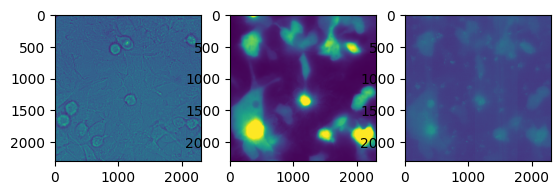

In [43]:
fig, axes = plt.subplots(ncols=nd2_img.dims.C)

for iC, ax in enumerate(axes):
    ax.imshow(nd2_img.data[0, iC, 0, :, :])

In [92]:
for bio_img in [czi_img, nd2_img, lif_img]:
    print(bio_img)
    print(isinstance(bio_img.reader, bioio_czi.Reader))
    # print(bio_img.ome_metadata.images[0].pixels.significant_bits)

<BioImage [reader: bioio-czi-pylibczirw, image-in-memory: True]>
True
<BioImage [plugin: bioio-nd2, image-in-memory: True]>
False
<BioImage [reader: bioio_lif, image-in-memory: True]>
False


In [79]:
czi_img.ome_metadata

OME(
   plates=[<1 field_type>],
   experimenters=[{'id': 'Experimenter:M1SRH', 'user_name': 'M1SRH'}],
   instruments=[<1 field_type>],
   images=[<1 field_type>],
   structured_annotations={'xml_annotations': [{'description': 'ZEN3.9.101.00000', 'id': 'urn:lsid:allencell.org:Annotation:AcquisitionSoftware', 'value': {}, 'kind': 'xmlannotation'}]},
)

In [99]:
from ome_types import from_xml
import xml.etree.ElementTree as ET
xml_metadata = lif_img.metadata
# from_xml(xml_metadata)
# xml_metadata = ET.tostring(lif_img.metadata, encoding='unicode')
# from_xml(xml_metadata)
bit_depth_tag = xml_metadata.find(".//SignificantBits")

if bit_depth_tag is not None:
    bit_depth = int(bit_depth_tag.text)
    print(f"Leica Acquisition Bit Depth: {bit_depth}")
else:
    # Fallback: check the numpy dtype if the tag is missing
    print(f"Tag not found. Container depth: {lif_img.dtype}")

AttributeError: 'int' object has no attribute 'text'

In [116]:
from lxml import etree
import xmltodict
import json

# 1. Get the raw Element object
xml_element = lif_img.metadata

# 2. Convert the Element object to a string
# 'unicode' ensures it's a standard string and not bytes
xml_str = ET.tostring(xml_element, encoding='unicode')

# 3. Convert XML string to a dictionary
metadata_dict = xmltodict.parse(xml_str)

# 4. Save as human-readable JSON
with open("readable_metadata.json", "w") as f:
    json.dump(metadata_dict, f, indent=4)

In [129]:
xml_element.findall(".//*[@BitSize]")[0].get("BitSize")

'8'

In [134]:
nd2_img.ome_metadata.images[0].pixels.significant_bits

16

# CellSePiImage Loader

# Misc

In [ ]:
from backend.main_window.data_util import FileType, CellSePiImage

for elem in FileType:
    print(elem.name)

In [11]:
from cellsepi.backend.main_window.data_util import FileType

np.where([elem == list(FileType)[2] for elem in FileType])[0].item()

ImportError: cannot import name 'FileType' from 'cellsepi.backend.main_window.data_util' (/Users/erik/Documents/Promotion/PythonProjects/CellSePi/src/cellsepi/backend/main_window/data_util.py)

In [17]:
from backend.main_window.constants import SourceType, FileType, DirectoryManager



['lif', 'nd2', 'czi']

In [18]:
pathlib.Path.home()

PosixPath('/Users/erik')

In [5]:
from backend.main_window.constants import FileType, SourceType, DirectoryManager
DirectoryManager().cache_directory

PosixPath('/Users/erik/.cellsepi/intermediate')

(160.0, 240.0)

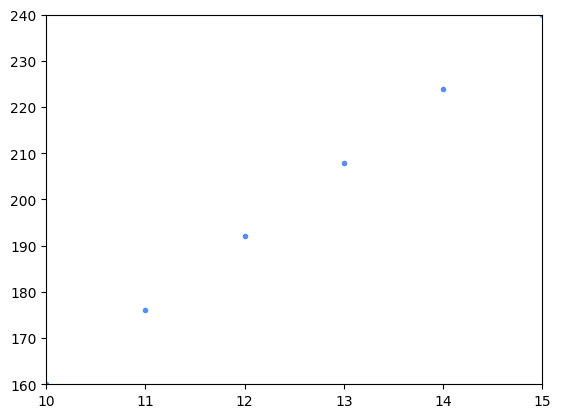

In [147]:
X = np.arange(256)
Y = [elem << 4 | elem >> 8 for elem in X]

fig, ax = plt.subplots()
ax.scatter(X, Y, marker=".")

ax.set_xlim((X[10], X[15]))
ax.set_ylim((Y[10], Y[15]))



In [148]:
np.diff(Y)

array([16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16